## Prompt Tuning and Instruction Fine Tuning Python Implementation

Install dependencies

In [ ]:
#PEFT - Parameter-Efficient Fine-Tuning
!pip install -q transformers datasets peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.7 MB/s eta 0:00:00


Import libraries

In [ ]:
#Import Required Libraries


import torch  # Torch: Core deep learning library for tensors and GPU acceleration
from datasets import load_dataset  # Datasets: Used to easily load and process text datasets

# Hugging Face Transformers: Provides pre-trained LLMs and training utilities
from transformers import (
    AutoTokenizer,            # Converts text into tokens the model understands
    AutoModelForSeq2SeqLM,    # Sequence-to-sequence model (used for text generation tasks)
    TrainingArguments,        # Defines hyperparameters (batch size, epochs, etc.)
    Trainer,                  # Handles the training loop automatically
    DataCollatorForSeq2Seq    # Prepares batches of tokenized data for training
)

# PEFT (Parameter-Efficient Fine-Tuning): For lightweight fine-tuning methods like Prompt Tuning
from peft import PromptTuningConfig, get_peft_model, TaskType

# Pandas: Useful for data manipulation (viewing, sampling datasets, etc.)
import pandas as pd

# re: Regular expressions for text preprocessing or cleaning
import re


Load a real dataset (Dolly 15k)

In [ ]:
dataset = load_dataset("databricks/databricks-dolly-15k")

# use 2000 samples for reasonable quality + quick runtime
small_dataset = dataset["train"].select(range(2000))

small_dataset[:3]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

{'instruction': ['When did Virgin Australia start operating?',
  'Which is a species of fish? Tope or Rope',
  'Why can camels survive for long without water?'],
 'context': ["Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
  '',
  ''],
 'response': ['Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.',
  'Tope',
  'Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.'],
 'category': ['closed_qa', 'classification', 'open_q

Load base model and tokenizer

In [ ]:
model_name = "google/flan-t5-small"  #base model
tokenizer = AutoTokenizer.from_pretrained(model_name)  #numeric tokens
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Preprocess dataset

In [ ]:
def preprocess_function(example):
    # Combine instruction text for the model input
    inputs = "Instruction: " + example["instruction"]

    # Expected output or answer
    outputs = example["response"]

    # Convert input text into numeric tokens (for the model to read)
    model_inputs = tokenizer(inputs, max_length=256, truncation=True)

    # Convert output text into numeric tokens (labels for training)
    labels = tokenizer(outputs, max_length=256, truncation=True)

    # Add labels (expected answers) to the input dictionary
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# Apply the preprocessing function to all dataset samples
tokenized_ds = small_dataset.map(preprocess_function)

# Split data: 90% for training, 10% for testing (evaluation)
tokenized_ds = tokenized_ds.train_test_split(test_size=0.1)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Part A — Prompt Tuning

In [ ]:
prompt_config = PromptTuningConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,        # Type of task: sequence-to-sequence (used in text generation tasks)
    num_virtual_tokens=10,                  # Number of virtual tokens to add and train
    tokenizer_name_or_path=model_name       # Use the same tokenizer as the base model
)

# Create a prompt-tuned version of the base model using the above configuration
prompt_tuned_model = get_peft_model(base_model, prompt_config)

# Print how many parameters are trainable vs frozen
prompt_tuned_model.print_trainable_parameters()


trainable params: 10,240 || all params: 76,971,392 || trainable%: 0.0133


Train prompt-tuned model

In [ ]:

prompt_args = TrainingArguments(
    output_dir="./prompt_tuning_output",  # Path to save the model
    per_device_train_batch_size=4,        # Batch size for training
    per_device_eval_batch_size=4,         # Batch size for evaluation
    num_train_epochs=5,                   # Number of times to iterate over the entire dataset
    learning_rate=3e-4,                   # Learning rate for the optimizer
    logging_steps=10,                     # How often to log training info
    save_total_limit=1,
    report_to="none"
)

# Prepare data for the model
data_collator = DataCollatorForSeq2Seq(tokenizer, model=prompt_tuned_model)
# Automatically pads sequences and prepares inputs and labels for Seq2Seq tasks

# Trainer setup
prompt_trainer = Trainer(
    model=prompt_tuned_model,             # Model to train
    args=prompt_args,                     # Training configurations
    train_dataset=tokenized_ds["train"], # Training dataset
    eval_dataset=tokenized_ds["test"],   # Evaluation dataset
    data_collator=data_collator           # How to batch and process the data
)


prompt_trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
10,3.450300
20,3.583500
30,3.497000
40,3.483500
50,3.498700
60,3.291300
70,3.511200
80,3.717800
90,3.490500
100,3.487600


Step,Training Loss
10,3.450300
20,3.583500
30,3.497000
40,3.483500
50,3.498700
60,3.291300
70,3.511200
80,3.717800
90,3.490500
100,3.487600


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=2250, training_loss=3.462904619852702, metrics={'train_runtime': 6170.1235, 'train_samples_per_second': 1.459, 'train_steps_per_second': 0.365, 'total_flos': 112276412571648.0, 'train_loss': 3.462904619852702, 'epoch': 5.0})

Part B — Instruction Fine-Tuning

In [ ]:
#Reload base model -> flan-t5-small
instruction_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


Train instruction-tuned model

In [ ]:
instruction_args = TrainingArguments(
    output_dir="./instruction_tuning_output",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    learning_rate=3e-5,   #smaller learning rate than the promt tuning
    logging_steps=10,
    save_total_limit=1,
    report_to="none"
)

instruction_trainer = Trainer(
    model=instruction_model,
    args=instruction_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    data_collator=data_collator
)

instruction_trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
10,3.411800
20,3.476200
30,3.367000
40,3.283300
50,3.381500
60,3.183900
70,3.327200
80,3.591200
90,3.328100
100,3.319400


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1350, training_loss=3.2539085487083153, metrics={'train_runtime': 5397.1597, 'train_samples_per_second': 1.001, 'train_steps_per_second': 0.25, 'total_flos': 67273483198464.0, 'train_loss': 3.2539085487083153, 'epoch': 3.0})

Compare Results (Text Outputs)

In [ ]:

def generate_text(model, instruction, context=""):
    # Combine instruction and context if provided
    if context.strip() != "":
        prompt = f"Instruction: {instruction}\nInput: {context}"
    else:
        prompt = f"Instruction: {instruction}"

    # Tokenize the input and convert to PyTorch tensors
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

    # Disable gradient calculation for inference
    with torch.no_grad():
        # Generate output tokens from the model
        output = model.generate(**inputs, max_new_tokens=50)

    # Decode token IDs back into human-readable text
    return tokenizer.decode(output[0], skip_special_tokens=True)


# 🧠 Test instructions to compare Prompt-Tuned vs Instruction-Fine-Tuned models
test_prompts = [
    {"instruction": "Why do humans need to sleep?"},
    {"instruction": "Generate a question based on this sentence:", "context": "Photosynthesis converts sunlight into energy."},
    {"instruction": "Summarize the following text:", "context": "Artificial Intelligence is changing the world rapidly."},
    {"instruction": "Explain what climate change is."},
    {"instruction": "Compare online learning and traditional classroom learning in two sentences."}
]

print("\n===== 🧠 Comparison: Prompt Tuning vs Instruction Fine-Tuning =====\n")

# Loop through each test instruction and get outputs from both models
for prompt in test_prompts:
    ins = prompt["instruction"]            # Instruction text
    ctx = prompt.get("context", "")        # Optional context
    out_prompt = generate_text(prompt_tuned_model, ins, ctx)    # Output from Prompt-Tuned model
    out_instr = generate_text(instruction_model, ins, ctx)      # Output from Instruction-Fine-Tuned model

    # Print results side by side for comparison
    print(f"🧠 Instruction: {ins}")
    if ctx:
        print(f"📘 Input: {ctx}")
    print(f"➡️ Prompt-Tuned Output: {out_prompt}")
    print(f"➡️ Instruction-Tuned Output: {out_instr}")
    print("-" * 80)



===== 🧠 Comparison: Prompt Tuning vs Instruction Fine-Tuning =====

🧠 Instruction: Why do humans need to sleep?
➡️ Prompt-Tuned Output: a sleeper is a human
➡️ Instruction-Tuned Output: sleep is a common cause of sleeplessness
--------------------------------------------------------------------------------
🧠 Instruction: Generate a question based on this sentence:
📘 Input: Photosynthesis converts sunlight into energy.
➡️ Prompt-Tuned Output: What is photosynthesis ?
➡️ Instruction-Tuned Output: What is photosynthesis ?
--------------------------------------------------------------------------------
🧠 Instruction: Summarize the following text:
📘 Input: Artificial Intelligence is changing the world rapidly.
➡️ Prompt-Tuned Output: Artificial intelligence is changing the world rapidly.
➡️ Instruction-Tuned Output: Artificial intelligence is changing the world.
--------------------------------------------------------------------------------
🧠 Instruction: Explain what climate change is.
➡

Visualize Training Loss

In [ ]:
logging_dir="./logs_prompt_tuning",       # Folder to save training logs (can be changed for each model)
logging_strategy="steps",                 # Record logs after a certain number of training steps
logging_steps=10,                         # Log training progress every 10 steps


In [ ]:
# Set up training configurations for the prompt-tuned model
prompt_args = TrainingArguments(
    output_dir="./prompt_tuning_output",     # Folder to save the trained model and outputs
    per_device_train_batch_size=2,           # Number of samples trained
    per_device_eval_batch_size=2,            # Number of samples evaluated
    num_train_epochs=3,
    learning_rate=1e-4,
    logging_dir="./logs_prompt_tuning",      # save path
    logging_strategy="steps",                # Log information after a set number of steps
    logging_steps=10,                        # Log training progress every 10 steps
    report_to="none"                         # Disable reporting to external tools (like WandB)
)


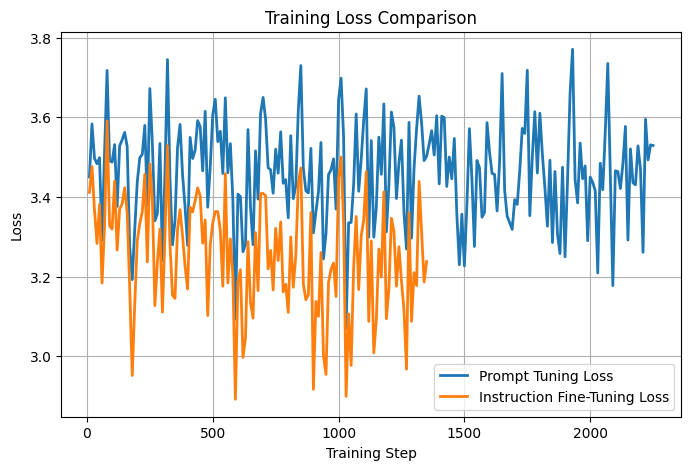

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract loss values from Trainer logs for both models
# Each Trainer automatically keeps a log of training progress (steps, loss, etc.)
prompt_logs = pd.DataFrame(prompt_trainer.state.log_history)
instruction_logs = pd.DataFrame(instruction_trainer.state.log_history)

# Keep only rows that contain 'loss' values (ignore evaluation or other logs)
prompt_losses = prompt_logs[prompt_logs["loss"].notnull()]
instruction_losses = instruction_logs[instruction_logs["loss"].notnull()]

# Create a plot to compare training loss of both models
plt.figure(figsize=(8,5))  # Set the size of the chart
plt.plot(prompt_losses["step"], prompt_losses["loss"], label="Prompt Tuning Loss", linewidth=2)
plt.plot(instruction_losses["step"], instruction_losses["loss"], label="Instruction Fine-Tuning Loss", linewidth=2)

# Add titles and labels to make the plot clear
plt.title("Training Loss Comparison")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


Save and Export Models

In [ ]:
prompt_tuned_model.save_pretrained("./prompt_tuned_model")
instruction_model.save_pretrained("./instruction_tuned_model")
tokenizer.save_pretrained("./tokenizer")


('./tokenizer/tokenizer_config.json',
 './tokenizer/special_tokens_map.json',
 './tokenizer/spiece.model',
 './tokenizer/added_tokens.json',
 './tokenizer/tokenizer.json')

Summary:


⚙️ Prompt Tuning

✅Trains only a few soft or virtual tokens while keeping the rest of the model frozen.

✅Fast and memory-efficient — suitable for limited hardware like Colab or laptops.

✅Requires less storage and shorter training time.

✅Works well for specific or narrow tasks (e.g., sentiment analysis, short Q&A).

✅May produce short or less detailed responses.


🚀 Instruction Fine-Tuning

✅Trains most or all model parameters for better adaptation.

✅Produces richer, context-aware, and coherent outputs.

✅Ideal for broad instruction-following tasks (summarization, reasoning, explanations).

✅Needs more time, memory, and computational power.

✅Commonly used for large-scale models like Flan-T5 or ChatGPT-style systems.

📌 When to Use Each

Prompt Tuning-

🎯Limited GPU or RAM

🎯Quick adaptation to a small dataset

Instruction Fine-Tuning -

🎯Large dataset and high-quality output needed

🎯Building a general-purpose chatbot or reasoning model

🏁 Key Takeaway

Prompt Tuning = Fast, lightweight, task-specific.

Instruction Fine-Tuning = Deep, powerful, versatile.

Choose based on your resources, goals, and dataset size.